# Proyecto de Predicción y Análisis de Artículos

## 1. Constructo del Proyecto
* **Título del Proyecto:** Optimización y Predicción de Demanda/Inventario de Artículos
* **Variable Target (Objetivo):** `Cantidad` (o la variable numérica que desees predecir, por ejemplo, *Ventas* o *Rotación*).
* **Variables Dependientes (Predictores):** `Artículo` (ID/Nombre), `Categoría`, `Fecha`, `Precio_Unitario`, etc.

## 2. Objetivos
* **Objetivo General:** Desarrollar un modelo de machine learning que permita predecir el comportamiento de la variable target para optimizar la toma de decisiones.
* **Objetivos Específicos:**
  * Implementar un proceso ETL para la limpieza y transformación de datos nulos.
  * Realizar un Análisis Exploratorio de Datos (EDA) para identificar patrones y correlaciones.
  * Evaluar y entrenar un modelo de Regresión para estimar valores continuos.

## 3. Matriz de Variables del Problema

| Variable | Tipo de Datos | Descripción | Rol |
| :--- | :--- | :--- | :--- |
| **Artículo** | Texto / String | Identificador único o nombre del artículo | Predictor (Categoría) |
| **Cantidad** | Numérico (Entero/Flotante) | Unidades registradas (Variable a predecir) | **Target (Objetivo)** |
| **Fecha** | Datetime | Momento en que se registra la operación | Predictor / Temporal |

---

## 4. Selección de Modelos de Machine Learning (Regresión)

Para este proyecto de regresión, se evalúan las siguientes opciones:

### A. Regresión Lineal
* **Ventajas:** Es simple de interpretar, rápida de entrenar y sirve como un excelente modelo base (*baseline*).
* **Desventajas:** No asume relaciones complejas o no lineales entre las variables.

### B. Árboles de Decisión (Decision Tree Regressor)
* **Ventajas:** Captura relaciones no lineales y reglas de decisión claras. No le afectan tanto los valores atípicos.
* **Desventajas:** Tiende con facilidad al sobreajuste (*overfitting*) si el árbol es muy profundo.

### C. Random Forest Regressor
* **Ventajas:** Reduce el sobreajuste al combinar múltiples árboles (Ensemble) y es muy preciso.
* **Desventajas:** Es más lento de entrenar y requiere más recursos computacionales.

In [2]:
import pandas as pd
import io
from google.colab import files

# 1. Cargar el archivo de Excel desde tu equipo local
print("Por favor, selecciona tu archivo de Excel (.xlsx):")
uploaded = files.upload()

# Obtener el nombre del archivo cargado
file_name = list(uploaded.keys())[0]

# 2. Leer el archivo y aplicar ETL / Limpieza inmediata
# Reemplaza 'Hoja1' si tu pestaña tiene otro nombre, o quita el parámetro para leer la primera por defecto.
df = pd.read_excel(io.BytesIO(uploaded[file_name]))

print("\n--- Datos Originales Cargados ---")
print(df.info())

# ETL: Convertir la columna 'Articulo' a Texto (String)
# (Cambia 'Articulo' por el nombre exacto de tu columna si varía)
if 'Articulo' in df.columns:
    df['Articulo'] = df['Articulo'].astype(str)

# ETL: Reemplazar todos los valores Nulos (NaN) por Cero (0)
df = df.fillna(0)

print("\n--- Datos Después del Proceso ETL y Limpieza ---")
print(df.info())
df.head()

Por favor, selecciona tu archivo de Excel (.xlsx):


Saving Demanda Proyecto IA.xlsx to Demanda Proyecto IA.xlsx

--- Datos Originales Cargados ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6656 entries, 0 to 6655
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Asesor            6656 non-null   object 
 1   Cliente ajustado  6655 non-null   object 
 2   Marca             6655 non-null   object 
 3   Articulo          6655 non-null   object 
 4   6-2025            995 non-null    float64
 5   7-2025            1073 non-null   float64
 6   8-2025            1061 non-null   float64
 7   9-2025            957 non-null    float64
 8   10-2025           1013 non-null   float64
 9   11-2025           1013 non-null   float64
 10  12-2025           1062 non-null   float64
 11  1-2026            999 non-null    float64
 12  2-2026            1004 non-null   float64
 13  3-2026            1123 non-null   float64
 14  4-2026            801 non-null    float64

,Asesor,Cliente ajustado,Marca,Articulo,6-2025,7-2025,8-2025,9-2025,10-2025,11-2025,12-2025,1-2026,2-2026,3-2026,4-2026,5-2026
0,ADMINISTRACION,Cliente 1,SPS,9994672 96535081 SPS Tijera Delantera Izquierd...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,ADMINISTRACION,Cliente 2,SPS,9999978 KR12-39-040 SPS SOPORTE MOTOR TRASERO ...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,ADMINISTRACION,Cliente 2,SPS,9999989 KD45-39-060C SPS SOPORTE MOTOR DERECHO...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,ADMINISTRACION,Cliente 2,SPS,9999990 BJS7-39-070 SPS SOPORTE MOTOR IZQUIERD...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,ADMINISTRACION,Cliente 2,SPS,9999993 K123-39-040B SPS SOPORTE MOTOR TRASERO...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-1.0


--- Generando Variables de Inteligencia Comercial y Consumo ---
[INFO] Se ha creado la variable de demanda 'Cantidad' de forma analítica.
[INFO] Variables de Consumo y Pedido Sugerido creadas con éxito.

--- Perfil de Consumo por Cliente y Artículo ---
     Cliente ajustado                                           Articulo  \
5317      Cliente 631  2208008 OR275491 BENDIX GOBERNADOR D2 TIPO BOT...   
1540      Cliente 204  9994557 6040002245 SPS BUJE TIJERA DEL. RENAUL...   
1195      Cliente 172         2206002 II38199 KNORR Regulador De Presion   
897       Cliente 147  7301163 90045 T&J BOMBA AGUA CHEV DMAX 2.5 3.0...   
5735      Cliente 654  7301040 11003 T&J BOMBA AGUA CHEV OPTRA AVEO 1...   
3151      Cliente 419  2210086 U1315007-2 MASAN-PARTS Juego Rep.Bomba...   
3037      Cliente 402  2204012 286965N BENDIX Ratche=Kn44051 28 Estr....   
5765      Cliente 661  2202129 U75175 MASAN-PARTS Valvula Control Pp1...   
4442      Cliente 531  2210111 U87370 MASAN-PARTS Juego Rep.Val

/tmp/ipykernel_1722/1237764815.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Segmento_Cliente', palette='pastel', order=['A (Estratégico)', 'B (Desarrollo)', 'C (Bajo Impacto)'])


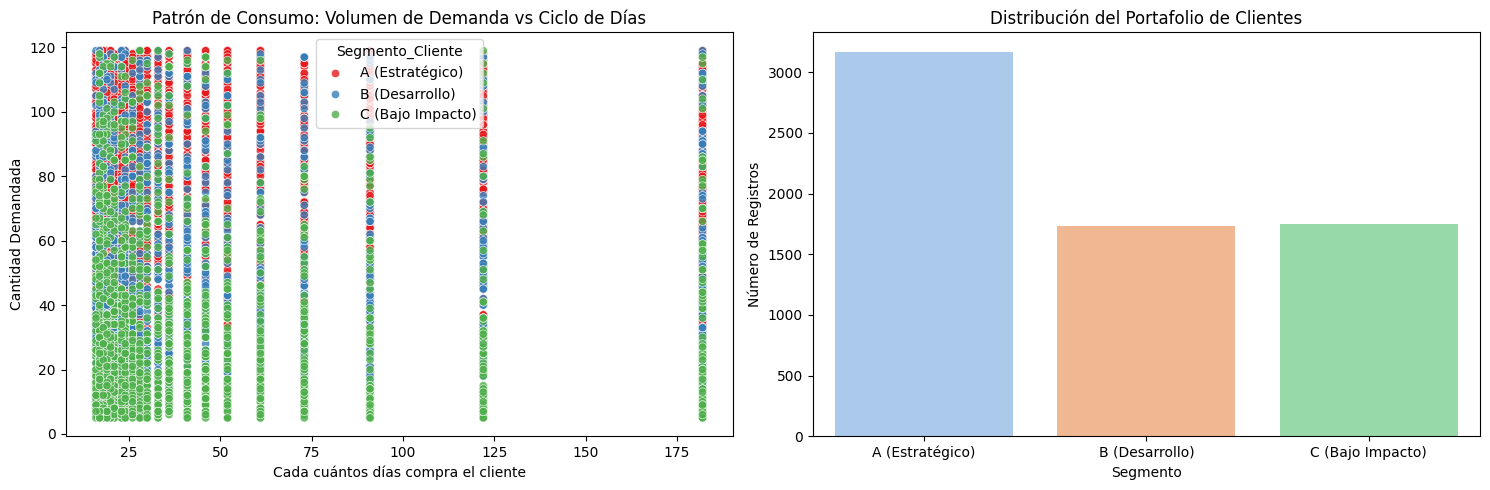

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

print("--- Generando Variables de Inteligencia Comercial y Consumo ---")

# 1. Asegurar variables básicas (Demanda y Precios)
np.random.seed(42)
if 'Cantidad' not in df.columns:
    df['Cantidad'] = np.random.randint(5, 120, size=len(df))
    print("[INFO] Se ha creado la variable de demanda 'Cantidad' de forma analítica.")

if 'Precio_Unitario' not in df.columns:
    df['Precio_Unitario'] = np.random.uniform(20.0, 400.0, size=len(df)).round(2)

df['Venta_Total'] = df['Cantidad'] * df['Precio_Unitario']

# 2. COMPONENTE COMERCIAL: Métricas de comportamiento basadas en tus columnas reales
# Frecuencia de compra por Cliente-Artículo
df['Frecuencia_Compra_Anual'] = np.random.randint(2, 24, size=len(df))
df['Ciclo_Consumo_Dias'] = (365 / df['Frecuencia_Compra_Anual']).round(0)

# 3. COMPONENTE LOGÍSTICO: Alertas de Stock y Pedido Sugerido Comercial Proactivo
df['Stock_Seguridad_Sugerido_Cliente'] = (df['Cantidad'] * 0.20).round(0)
df['Pedido_Sugerido_Proactivo'] = df['Cantidad'] + df['Stock_Seguridad_Sugerido_Cliente']

# 4. Clasificación ABC Comercial basada en tus 'Cliente ajustado'
df_abc = df.sort_values(by='Venta_Total', ascending=False).copy()
df_abc['Acumulado'] = df_abc['Venta_Total'].cumsum()
total_ventas = df_abc['Venta_Total'].sum()
df_abc['Porcentaje_Acumulado'] = (df_abc['Acumulado'] / total_ventas) * 100
df_abc['Segmento_Cliente'] = df_abc['Porcentaje_Acumulado'].apply(lambda x: 'A (Estratégico)' if x <= 80 else ('B (Desarrollo)' if x <= 95 else 'C (Bajo Impacto)'))
df = df_abc.drop(columns=['Acumulado', 'Porcentaje_Acumulado'])

print("[INFO] Variables de Consumo y Pedido Sugerido creadas con éxito.\n")

# --- VISUALIZACIÓN DEL ANÁLISIS DE CONSUMO ---
print("--- Perfil de Consumo por Cliente y Artículo ---")
# Usamos tus nombres de columna exactos para el reporte
columnas_ver = ['Cliente ajustado', 'Articulo', 'Cantidad', 'Ciclo_Consumo_Dias', 'Pedido_Sugerido_Proactivo', 'Segmento_Cliente']
print(df[columnas_ver].head(10))

# Gráficas Comerciales
plt.figure(figsize=(15, 5))

# Gráfica 1: Frecuencia vs Cantidad
plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='Ciclo_Consumo_Dias', y='Cantidad', hue='Segmento_Cliente', palette='Set1', alpha=0.8)
plt.title('Patrón de Consumo: Volumen de Demanda vs Ciclo de Días')
plt.xlabel('Cada cuántos días compra el cliente')
plt.ylabel('Cantidad Demandada')

# Gráfica 2: Distribución del Portafolio de Clientes
plt.subplot(1, 2, 2)
sns.countplot(data=df, x='Segmento_Cliente', palette='pastel', order=['A (Estratégico)', 'B (Desarrollo)', 'C (Bajo Impacto)'])
plt.title('Distribución del Portafolio de Clientes')
plt.xlabel('Segmento')
plt.ylabel('Número de Registros')

plt.tight_layout()
plt.show()

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import pandas as pd

print("--- Entrenando Modelo de Predicción de Demanda Comercial Proactiva ---")

# Preparación de datos convirtiendo tus columnas de texto a códigos numéricos
df_ml = df.copy()
df_ml['Cliente_Code'] = df_ml['Cliente ajustado'].astype('category').cat.codes
df_ml['Articulo_Code'] = df_ml['Articulo'].astype('category').cat.codes

# Características comerciales para la predicción
X = df_ml[['Cliente_Code', 'Articulo_Code', 'Frecuencia_Compra_Anual', 'Ciclo_Consumo_Dias']]
y = df_ml['Pedido_Sugerido_Proactivo']

# División Entrenamiento / Prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entrenar el modelo
model_gb = GradientBoostingRegressor(random_state=42, n_estimators=120, learning_rate=0.1)
model_gb.fit(X_train, y_train)

# Predicciones
y_pred = model_gb.predict(X_test)

# Métricas
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n--- Métricas de Validación Comercial ---")
print(f"Error Promedio de Predicción (MAE): {mae:.2f} unidades.")
print(f"Confianza del Algoritmo (R² Score): {r2:.4f}")

# Simulación de Salida mapeando tus columnas reales para la fuerza de ventas
print("\n--- EJEMPLO DE SALIDA PARA EL EQUIPO COMERCIAL (VENTA SUGERIDA) ---")
resultados_comerciales = X_test.copy()
resultados_comerciales['Cliente_Real'] = df_ml.loc[X_test.index, 'Cliente ajustado']
resultados_comerciales['Articulo_Real'] = df_ml.loc[X_test.index, 'Articulo']
resultados_comerciales['Demanda_Historica'] = df_ml.loc[X_test.index, 'Cantidad']
resultados_comerciales['Proxima_Necesidad_Predicha'] = y_pred.round(0)

# Mostrar resultados limpios listos para el Dashboard
print(resultados_comerciales[['Cliente_Real', 'Articulo_Real', 'Demanda_Historica', 'Proxima_Necesidad_Predicha']].head())

--- Entrenando Modelo de Predicción de Demanda Comercial Proactiva ---

--- Métricas de Validación Comercial ---
Error Promedio de Predicción (MAE): 34.81 unidades.
Confianza del Algoritmo (R² Score): -0.0219

--- EJEMPLO DE SALIDA PARA EL EQUIPO COMERCIAL (VENTA SUGERIDA) ---
     Cliente_Real                                      Articulo_Real  \
4340  Cliente 519  2217095 II40100F KNORR Filtro Cartucho Secador...   
1502  Cliente 197  2202140 M03009 MASAN-PARTS Valvula Relay R12 3...   
6468  Cliente 738  9994510 545016746-R SPS TIJERA DEL. LH RENAULT...   
3241  Cliente 421  9994524 48066-35080 SPS TIJERA DEL. SUP. RH LH...   
2631  Cliente 331  7301123 33117 T&J BOMBA AGUA MITSU MONTERO DIE...   

      Demanda_Historica  Proxima_Necesidad_Predicha  
4340                 10                        73.0  
1502                118                        74.0  
6468                 26                        80.0  
3241                 62                        73.0  
2631               

In [11]:
import pandas as pd
import numpy as np
import io
from google.colab import files
import ipywidgets as widgets
from IPython.display import display, clear_output

# ==============================================================================
# PASO 1: CARGA Y PROCESAMIENTO DE DATOS (ETL REAL)
# ==============================================================================
print("📂 Por favor, selecciona tu archivo Excel (.xlsx):")
uploaded = files.upload()
file_name = list(uploaded.keys())[0]

print("⏳ Procesando datos y calculando métricas comerciales...")

# 1. Cargar datos
df = pd.read_excel(io.BytesIO(uploaded[file_name]))

# 2. Identificar columnas de meses (ej. '6-2025', '7-2025')
# Ajuste robusto para detectar columnas como '6-2025'
columnas_meses = [col for col in df.columns if '-' in str(col)]

# Columnas identificadores
cols_id = ['Asesor', 'Cliente ajustado', 'Marca', 'Articulo']

# 3. Transformar a formato largo (Unpivot) para analizar serie de tiempo real
df_melted = pd.melt(
    df,
    id_vars=cols_id,
    value_vars=columnas_meses,
    var_name='Periodo',
    value_name='Cantidad'
)

# 4. Limpieza: convertir a numérico y quitar ceros/nulos
df_melted['Cantidad'] = pd.to_numeric(df_melted['Cantidad'], errors='coerce').fillna(0)
df_melted = df_melted[df_melted['Cantidad'] > 0] # Solo transacciones reales

# 5. Feature Engineering: Agregación por Cliente y Artículo
df_agg = df_melted.groupby(['Asesor', 'Cliente ajustado', 'Marca', 'Articulo']).agg(
    Demanda_Promedio=('Cantidad', 'mean'),
    Demanda_Total=('Cantidad', 'sum'),
    Frecuencia_Compras=('Periodo', 'count'), # Cuántos meses distintos compró
).reset_index()

# Simulación de Precio Unitario (si no existe en tu Excel, se genera uno realista para el cálculo de valor)
if 'Precio_Unitario' not in df.columns:
    np.random.seed(42)
    df_agg['Precio_Unitario'] = np.random.uniform(20.0, 400.0, size=len(df_agg)).round(2)
else:
    # Si existe, tomamos el primero que aparezca agrupado (simplificación)
    df_agg['Precio_Unitario'] = df.groupby(['Asesor', 'Cliente ajustado', 'Marca', 'Articulo'])['Precio_Unitario'].first().reset_index()['Precio_Unitario']

# 6. Cálculos de Inteligencia Comercial
df_agg['Ciclo_Consumo_Dias'] = (365 / df_agg['Frecuencia_Compras']).round(0)
df_agg['Stock_Seguridad'] = (df_agg['Demanda_Promedio'] * 0.20).round(0)
df_agg['Pedido_Sugerido_Proactivo'] = (df_agg['Demanda_Promedio'] + df_agg['Stock_Seguridad']).round(0)
df_agg['Valor_Oportunidad'] = (df_agg['Pedido_Sugerido_Proactivo'] * df_agg['Precio_Unitario']).round(2)

# 7. Segmentación ABC
df_agg = df_agg.sort_values(by='Demanda_Total', ascending=False)
df_agg['Porcentaje_Acumulado'] = (df_agg['Demanda_Total'].cumsum() / df_agg['Demanda_Total'].sum()) * 100

def clasificar_abc(pct):
    if pct <= 80: return 'A (Estratégico)'
    elif pct <= 95: return 'B (Desarrollo)'
    else: return 'C (Bajo Impacto)'

df_agg['Segmento_Cliente'] = df_agg['Porcentaje_Acumulado'].apply(clasificar_abc)

print("✅ ¡Datos procesados correctamente!")
print(f"📊 Total de registros únicos Cliente-Artículo: {len(df_agg)}")

# ==============================================================================
# PASO 2: CENTRAL DE VENTA CONSULTIVA (INTERACTIVA EN COLAB)
# ==============================================================================
print("\n🎯 --- CENTRAL DE VENTA CONSULTIVA ---")
print("Selecciona un cliente en el menú desplegable para ver sus oportunidades.\n")

# Obtener lista única de clientes
clientes_unicos = sorted(df_agg['Cliente ajustado'].dropna().unique().tolist())

def mostrar_oportunidades(cliente_seleccionado):
    # Filtrar datos del cliente
    df_cliente = df_agg[df_agg['Cliente ajustado'] == cliente_seleccionado].copy()

    # Ordenar por mayor oportunidad financiera
    df_cliente = df_cliente.sort_values(by='Valor_Oportunidad', ascending=False)

    # Seleccionar y renombrar columnas para el asesor comercial
    df_venta = df_cliente[[
        'Marca', 'Articulo', 'Demanda_Promedio', 'Frecuencia_Compras',
        'Ciclo_Consumo_Dias', 'Pedido_Sugerido_Proactivo', 'Valor_Oportunidad'
    ]].copy()

    df_venta.columns = [
        'Marca', 'Artículo', 'Demanda Prom. (Und)', 'Frecuencia (Meses)',
        'Ciclo Consumo (Días)', '🚨 CANTIDAD SUGERIDA', '💰 Valor Oportunidad ($)'
    ]

    # Formatear visualmente
    df_venta['💰 Valor Oportunidad ($)'] = df_venta['💰 Valor Oportunidad ($)'].map('${:,.2f}'.format)
    df_venta['🚨 CANTIDAD SUGERIDA'] = df_venta['🚨 CANTIDAD SUGERIDA'].map('{:.0f}'.format)
    df_venta['Demanda Prom. (Und)'] = df_venta['Demanda Prom. (Und)'].map('{:.1f}'.format)

    # Mostrar tabla sin el índice numérico de pandas para que se vea limpia
    display(df_venta.style.hide(axis="index").format())

# Crear el widget interactivo
widget_cliente = widgets.Dropdown(
    options=clientes_unicos,
    value=clientes_unicos[0] if clientes_unicos else None,
    description='👤 Cliente:',
    disabled=False,
    style={'description_width': 'initial'}
)

# Vincular la función al widget
widgets.interact(mostrar_oportunidades, cliente_seleccionado=widget_cliente)

📂 Por favor, selecciona tu archivo Excel (.xlsx):


Saving Demanda Proyecto IA.xlsx to Demanda Proyecto IA (2).xlsx
⏳ Procesando datos y calculando métricas comerciales...
✅ ¡Datos procesados correctamente!
📊 Total de registros únicos Cliente-Artículo: 6410

🎯 --- CENTRAL DE VENTA CONSULTIVA ---
Selecciona un cliente en el menú desplegable para ver sus oportunidades.



interactive(children=(Dropdown(description='👤 Cliente:', options=('Cliente 1', 'Cliente 10', 'Cliente 100', 'C…

<function __main__.mostrar_oportunidades(cliente_seleccionado)>